In [1]:
import pprint as pp

import numpy as np
import matplotlib.pyplot as plt

from ard.utils.io import load_yaml
from ard.api import set_up_ard_model
from ard.viz.layout import plot_layout
import openmdao.api as om

Running OpenMDAO util to clean the output directories...
	Found 1 OpenMDAO output directories:
	Removed case_files/ard_problem_out
	Removed 1 OpenMDAO output directories.
... done.

Created top-level OpenMDAO problem: top_level.
Adding top_level.
    Adding layout2aep.
        Adding layout to layout2aep.
        Adding aepFLORIS to layout2aep.
	Activating approximate totals on layout2aep
    Adding boundary.
    Adding landuse.
    Adding collection.
    Adding spacing_constraint.
    Adding tcc.
    Adding landbosse.
    Adding opex.
    Adding financese.
System top_level built.
System top_level set up.


floris.floris_model.FlorisModel WARNING turbine_type has been changed without specifying a new reference_wind_height. reference_wind_height remains 90.00 m. Consider calling `FlorisModel.assign_hub_height_to_ref_height` to update the reference wind height to the turbine hub height.
floris.floris_model.FlorisModel WARNING Computing AEP with uniform frequencies. Results results may not reflect annual operation.




RESULTS:

{'AEP_val': 438.2972215894054,
 'BOS_val': 100.65412521292292,
 'CapEx_val': 422.5,
 'LCOE_val': 122.14670035285323,
 'OpEx_val': 14.300000000000002,
 'area_tight': 43.480869670526026,
 'coll_length': 58.59866989604397,
 'turbine_spacing': 0.88116065576}





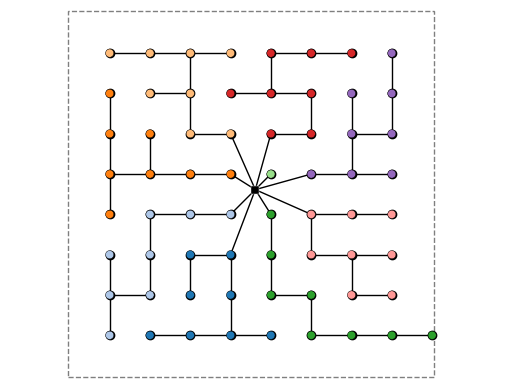

<Axes: >

In [ ]:
# load input
input_dict = load_yaml("./inputs/ard_system.yaml")

# set up system
prob = set_up_ard_model(input_dict=input_dict, root_data_path="inputs")

if False:
    # visualize model
    om.n2(prob)

# run the model
prob.run_model()

# collapse the test result data
test_data = {
    "AEP_val": float(prob.get_val("AEP_farm", units="GW*h")[0]),
    "CapEx_val": float(prob.get_val("tcc.tcc", units="MUSD")[0]),
    "BOS_val": float(prob.get_val("landbosse.total_capex", units="MUSD")[0]),
    "OpEx_val": float(prob.get_val("opex.opex", units="MUSD/yr")[0]),
    "LCOE_val": float(prob.get_val("financese.lcoe", units="USD/MW/h")[0]),
    "area_tight": float(prob.get_val("landuse.area_tight", units="km**2")[0]),
    "coll_length": float(prob.get_val("total_length_cables", units="km")[0]),
    "turbine_spacing": float(
        np.min(prob.get_val("spacing_constraint.turbine_spacing", units="km"))
    ),
}

print("\n\nRESULTS:\n")
pp.pprint(test_data)
print("\n\n")

if False:
    plot_layout(
        prob, input_dict=input_dict, show_image=True, include_cable_routing=True
    )

In [3]:
optimize = False  # set to False to skip optimization

if optimize:

    # run the optimization
    prob.run_driver()
    prob.cleanup()

    # collapse the test result data
    test_data = {
        "AEP_val": float(prob.get_val("AEP_farm", units="GW*h")[0]),
        "CapEx_val": float(prob.get_val("tcc.tcc", units="MUSD")[0]),
        "BOS_val": float(prob.get_val("landbosse.total_capex", units="MUSD")[0]),
        "OpEx_val": float(prob.get_val("opex.opex", units="MUSD/yr")[0]),
        "LCOE_val": float(prob.get_val("financese.lcoe", units="USD/MW/h")[0]),
        "area_tight": float(prob.get_val("landuse.area_tight", units="km**2")[0]),
        "coll_length": float(prob.get_val("total_length_cables", units="km")[0]),
        "turbine_spacing": float(
            np.min(prob.get_val("spacing_constraint.turbine_spacing", units="km"))
        ),
    }

    # clean up the recorder
    prob.cleanup()

    # print the results
    print("\n\nRESULTS (opt):\n")
    pp.pprint(test_data)
    print("\n\n")

    plot_layout(
        prob, input_dict=input_dict, show_image=True, include_cable_routing=True
    )